In [2]:
import pandas as pd
import numpy as np
import ast
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
from tqdm import tqdm
import warnings
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim

In [3]:
df = pd.read_csv('../Data/train_wd_hc.csv', index_col = 0)

df.reset_index(drop=True, inplace = True)
df.drop(columns = ['id'], inplace= True)

df_x = df[['transfer', 'outer', 'terminal', 'cbd', 'tfa_r', 'tfa_c',
       'tfa_w', 'univ', 'pop', 'job', 'bus', 'buld_sum', 'rest', 'green',
       'tfa_n', 'tfa_f', 'lumix']]
df_y = df[['pattern', 'max_ride', 'min_ride']]

df_x = df_x.apply(lambda col: col.fillna(col.min()), axis=0)

# Parse pattern strings to lists and denormalize
def denormalize_pattern(pattern_str, min_ride, max_ride):
    # Convert string representation to list
    pattern_list = ast.literal_eval(pattern_str)
    # Denormalize: value * (max_ride - min_ride) + min_ride
    denormalized = [val * (max_ride - min_ride) + min_ride for val in pattern_list]
    return np.array(denormalized)

# Apply to each row
df_y['ridership'] = df_y.apply(
    lambda row: denormalize_pattern(row['pattern'], row['min_ride'], row['max_ride']),
    axis=1
)

print(len(df))

226


C:\Users\id310624\AppData\Local\Temp\ipykernel_14036\2559102360.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_y['ridership'] = df_y.apply(


In [4]:
# Get English name
df_enname = pd.read_csv('../Data/서울교통공사_역명다국어표기_20241101.csv', encoding = 'cp949')
df_enname['한글'] = df_enname['한글'].apply(lambda x: x.split('(')[0])
df_enname.drop_duplicates(subset=['한글'], inplace=True)
df_enname.rename(columns={'한글':'name', '영문':'en_name'}, inplace=True)
df = df.merge(df_enname[['name', 'en_name']], on = 'name', how='left', suffixes=('', '_y'))

df.loc[df['name'] == '미아사거리', 'en_name'] = 'MiaSageori'
df.loc[df['name'] == '뚝섬유원지', 'en_name'] = 'DduksomPark'
df.loc[df['name'] == '화랑대', 'en_name'] = 'Hwarangdae'
df.loc[df['name'] == '서울', 'en_name'] = 'SeoulStation'

df = df[['name', 'en_name', 'transfer', 'outer', 'terminal', 'cbd', 'tfa_r', 'tfa_c',
       'tfa_w', 'univ', 'pop', 'job', 'bus', 'buld_sum', 'rest', 'green',
       'tfa_n', 'tfa_f', 'lumix', 'index', 'weekend', 'hacha', 'max_ride',
       'min_ride', 'pattern', 'cA', 'cD']]
df[df['en_name'].isna()]

,name,en_name,transfer,outer,terminal,cbd,tfa_r,tfa_c,tfa_w,univ,...,tfa_f,lumix,index,weekend,hacha,max_ride,min_ride,pattern,cA,cD


In [5]:
train_id = list(df[~df['name'].isin(['태릉입구', '상봉', '상도', '강남', '시청', '공덕'])].index)
test_id = list(df[df['name'].isin(['태릉입구', '상봉', '상도', '강남', '시청', '공덕'])].index)

train_data_x = df_x.iloc[train_id]
train_data_y = df_y['ridership'].iloc[train_id]

test_data_x = df_x.iloc[test_id]
test_data_y = df_y['ridership'].iloc[test_id]

train_input = train_data_x
train_output = train_data_y
val_input = test_data_x
val_output = test_data_y    

x_stacks, y_stacks = [], []

for k, row in train_input.iterrows():
    # repeat df_x row for 20 time steps and stack with one-hot time vectors and ridership
    x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)
    ridership_vals = np.array(train_output.loc[k]).reshape(-1, 1)
    ridership_vals = np.where(ridership_vals == 0, 1, ridership_vals) # avoid log(0)
    temp_stack = np.hstack([time_onehots, x_rep])
    x_stacks.append(temp_stack)
    y_stacks.append(ridership_vals)

train_x, train_y = np.vstack(x_stacks), np.vstack(y_stacks)


# Regression

In [6]:
# Fit linear regression model with log-transformed target
reg_model = LinearRegression()
reg_model.fit(train_x, np.log(train_y.flatten()))

# Get R² value
r2_score = reg_model.score(train_x, np.log(train_y.flatten()))
print(f"R² Score: {r2_score:.6f}")

# Calculate VIF for multicollinearity test
vif_data = []
for i in range(train_x.shape[1]):
    vif = variance_inflation_factor(train_x, i)
    vif_data.append(vif)

print("\nVariance Inflation Factor (VIF) - Multicollinearity Test:")
print(f"{'Feature':<10} {'VIF':<15} {'Status':<20}")
print("-" * 45)
for i, vif in enumerate(vif_data):
    status = "High multicollinearity" if vif > 10 else ("Moderate" if vif > 5 else "Low")
    print(f"{i:<10} {vif:<15.4f} {status:<20}")

print(f"\nMean VIF: {np.mean(vif_data):.4f}")
print(f"Max VIF: {np.max(vif_data):.4f}")
print(f"\nModel Intercept: {reg_model.intercept_:.6f}")

R² Score: 0.676817


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



Variance Inflation Factor (VIF) - Multicollinearity Test:
Feature    VIF             Status              
---------------------------------------------
0          1.9763          Low                 
1          1.9763          Low                 
2          1.9763          Low                 
3          1.9763          Low                 
4          1.9763          Low                 
5          1.9763          Low                 
6          1.9763          Low                 
7          1.9763          Low                 
8          1.9763          Low                 
9          1.9763          Low                 
10         1.9763          Low                 
11         1.9763          Low                 
12         1.9763          Low                 
13         1.9763          Low                 
14         1.9763          Low                 
15         1.9763          Low                 
16         1.9763          Low                 
17         1.9763          Low 

In [25]:
# Remove high VIF features iteratively and refit regression
# Build DataFrame for features with names: time_0..time_19 + original feature names
col_names = [f"time_{i}" for i in range(20)] + list(train_input.columns)
df_train_x = pd.DataFrame(train_x, columns=col_names)

def compute_vif(df):
    vif_vals = []
    X = df.values.astype(float)
    for i in range(X.shape[1]):
        try:
            vif_vals.append(variance_inflation_factor(X, i))
        except Exception:
            vif_vals.append(np.inf)
    return pd.Series(vif_vals, index=df.columns)

# Iteratively remove features with VIF > 10 (or inf)
df_vif = compute_vif(df_train_x)
removed = []
while True:
    max_vif = df_vif.max()
    if not np.isfinite(max_vif) or max_vif > 10:
        drop_col = df_vif.idxmax()
        removed.append((drop_col, float(df_vif.max())))
        df_train_x = df_train_x.drop(columns=[drop_col])
        df_vif = compute_vif(df_train_x)
    else:
        break

print("Removed features (col, vif):", removed)
print("Remaining features:", list(df_train_x.columns))

# Refit linear regression on reduced feature set
reg_model_reduced = LinearRegression()
reg_model_reduced.fit(df_train_x.values, np.log(train_y.flatten()))
r2_reduced = reg_model_reduced.score(df_train_x.values, np.log(train_y.flatten()))

# Final VIF summary
final_vif = compute_vif(df_train_x)
print(f"R² Score (reduced): {r2_reduced:.6f}")
print(f"Mean VIF (reduced): {final_vif.mean():.4f}")
print(f"Max VIF (reduced): {final_vif.max():.4f}")
print("Top VIFs:\n", final_vif.sort_values(ascending=False).head(10))

# Replace original reg_model with the reduced one for downstream cells
reg_model = reg_model_reduced
train_x = df_train_x.values

Removed features (col, vif): [('tfa_r', inf)]
Remaining features: ['time_0', 'time_1', 'time_2', 'time_3', 'time_4', 'time_5', 'time_6', 'time_7', 'time_8', 'time_9', 'time_10', 'time_11', 'time_12', 'time_13', 'time_14', 'time_15', 'time_16', 'time_17', 'time_18', 'time_19', 'transfer', 'outer', 'terminal', 'cbd', 'tfa_c', 'tfa_w', 'univ', 'pop', 'job', 'bus', 'buld_sum', 'rest', 'green', 'tfa_n', 'tfa_f', 'lumix']
R² Score (reduced): 0.676817
Mean VIF (reduced): 2.4088
Max VIF (reduced): 7.4797
Top VIFs:
 buld_sum    7.479731
tfa_n       6.445104
job         5.579973
tfa_w       4.527416
pop         3.791770
rest        3.429072
lumix       2.401503
tfa_c       2.251403
tfa_f       2.122907
time_19     1.976283
dtype: float64


In [26]:
warnings.filterwarnings('ignore')

mse = 0

for k, row in tqdm(val_input.iterrows(), total=len(val_input), desc="Validation"):
    # repeat df_x row for 20 time steps and stack with one-hot time vectors
    x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)
    ridership_vals = np.array(val_output.loc[k]).reshape(-1, 1)
    ridership_vals = np.where(ridership_vals == 0, 1, ridership_vals)
    temp_stack = np.hstack([time_onehots, x_rep])
    
    # Make predictions using the linear regression model
    preds = reg_model.predict(temp_stack)
    
    ridership_flat = np.log(ridership_vals).flatten()
    
    # record results and update mse
    mse += np.mean(np.abs(preds.flatten() - ridership_flat))
    
    # plot actual (grey) vs predicted (red)
    plt.figure(figsize=(8, 4))
    plt.plot(range(len(ridership_flat)), ridership_flat, color='grey', marker='o', label='actual')
    plt.plot(range(len(preds)), preds, color='red', marker='o', label='predicted')
    

    # station name
    st_name = df.loc[k]['en_name']


    for t in range(len(ridership_flat)):
        plt.text(t, float(ridership_flat[t]), f"{float(ridership_flat[t]):.2f}", color='grey', ha='center', va='bottom', fontsize=8)
        plt.text(t, float(preds[t]), f"{float(preds[t]):.2f}", color='red', ha='center', va='bottom', fontsize=8)
        plt.xlabel('time')
    plt.ylabel('ridership (log scale)')
    plt.title(f'Validation idx={st_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

print(f"Mean Absolute Error: {mse / len(val_input):.6f}")


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

ValueError: X has 37 features, but LinearRegression is expecting 36 features as input.

# DNN

In [7]:
# Convert numpy arrays to torch tensors
train_x_tensor = torch.FloatTensor(train_x)
train_y_tensor = torch.FloatTensor(np.log(train_y))

# Create dataset and dataloader
dataset = TensorDataset(train_x_tensor, train_y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Define DNN model: 37 input -> 20 hidden -> 10 hidden -> 20 output
class DNN(nn.Module):
    def __init__(self):
        super(DNN, self).__init__()
        self.fc1 = nn.Linear(37, 20)
        self.fc2 = nn.Linear(20, 10)
        self.fc3 = nn.Linear(10, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize model
dnn_model = DNN()
optimizer = optim.Adam(dnn_model.parameters())
criterion = nn.MSELoss()

# Training loop
num_epochs = 5000
for epoch in range(num_epochs):
    total_loss = 0
    for batch_x, batch_y in dataloader:
        outputs = dnn_model(batch_x)
        loss = criterion(outputs, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(dataloader):.4f}')

print("Training complete!")
# print(dnn_model)

Epoch [10/5000], Loss: 0.3796
Epoch [20/5000], Loss: 0.2956
Epoch [30/5000], Loss: 0.2573
Epoch [40/5000], Loss: 0.2275
Epoch [50/5000], Loss: 0.2017
Epoch [60/5000], Loss: 0.1865
Epoch [70/5000], Loss: 0.1793
Epoch [80/5000], Loss: 0.1714
Epoch [90/5000], Loss: 0.1637
Epoch [100/5000], Loss: 0.1567
Epoch [110/5000], Loss: 0.1523
Epoch [120/5000], Loss: 0.1492
Epoch [130/5000], Loss: 0.1442
Epoch [140/5000], Loss: 0.1418
Epoch [150/5000], Loss: 0.1361
Epoch [160/5000], Loss: 0.1347
Epoch [170/5000], Loss: 0.1315
Epoch [180/5000], Loss: 0.1330
Epoch [190/5000], Loss: 0.1268
Epoch [200/5000], Loss: 0.1265
Epoch [210/5000], Loss: 0.1287
Epoch [220/5000], Loss: 0.1238
Epoch [230/5000], Loss: 0.1246
Epoch [240/5000], Loss: 0.1207
Epoch [250/5000], Loss: 0.1191
Epoch [260/5000], Loss: 0.1197
Epoch [270/5000], Loss: 0.1176
Epoch [280/5000], Loss: 0.1169
Epoch [290/5000], Loss: 0.1181
Epoch [300/5000], Loss: 0.1152
Epoch [310/5000], Loss: 0.1138
Epoch [320/5000], Loss: 0.1130
Epoch [330/5000],

In [8]:
# Save DNN parameters (state_dict) and full model
torch.save(dnn_model.state_dict(), 'dnn_model_state.pth')
torch.save(dnn_model, 'dnn_model_full.pth')

print("Saved: dnn_model_state.pth, dnn_model_full.pth")

Saved: dnn_model_state.pth, dnn_model_full.pth


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

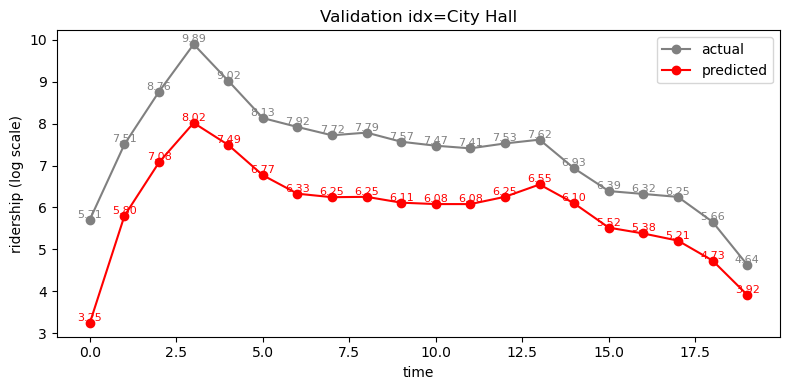

Validation:  17%|█▋        | 1/6 [00:01<00:05,  1.04s/it]

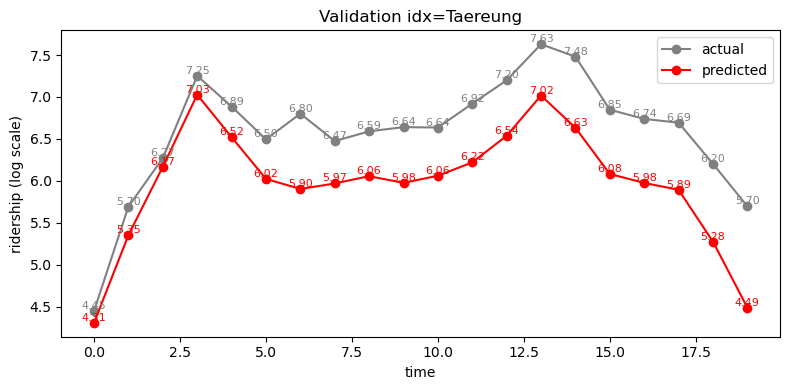

Validation:  33%|███▎      | 2/6 [00:01<00:03,  1.26it/s]

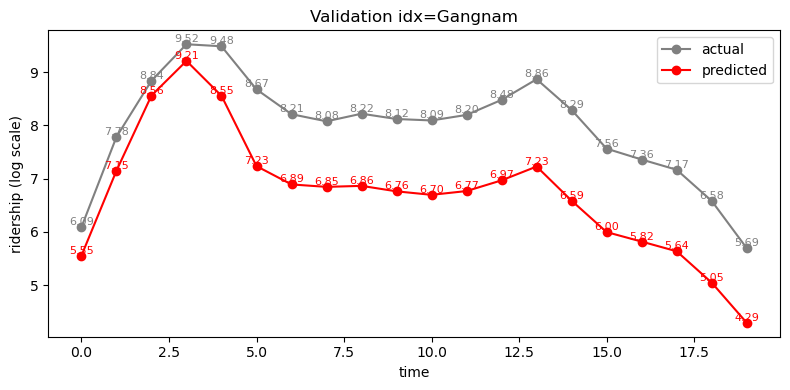

Validation:  50%|█████     | 3/6 [00:02<00:02,  1.35it/s]

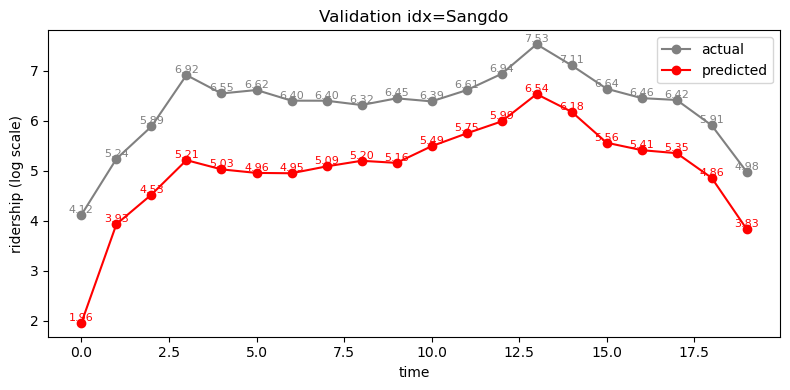

Validation:  67%|██████▋   | 4/6 [00:02<00:01,  1.58it/s]

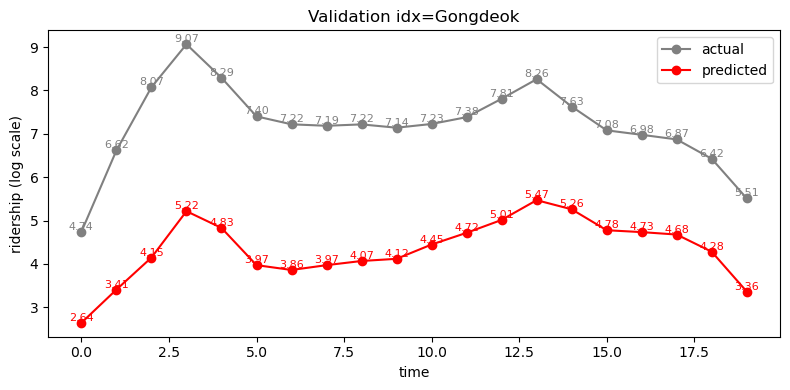

Validation:  83%|████████▎ | 5/6 [00:03<00:00,  1.85it/s]

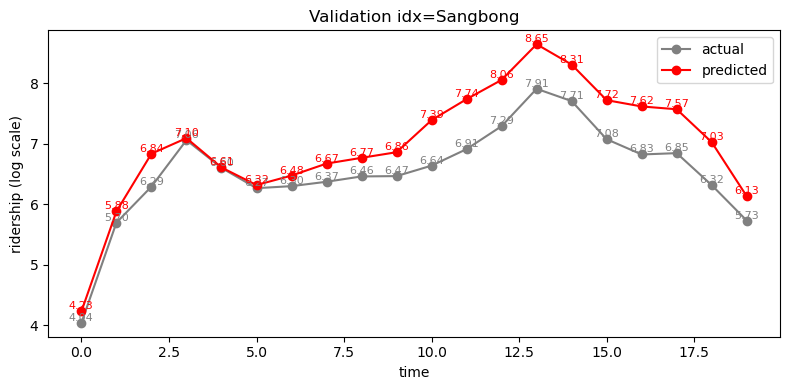

Validation: 100%|██████████| 6/6 [00:03<00:00,  1.63it/s]

Mean Absolute Error: 1.291807


In [47]:
warnings.filterwarnings('ignore')

mse = 0

for k, row in tqdm(val_input.iterrows(), total=len(val_input), desc="Validation"):
    # repeat df_x row for 20 time steps and stack with one-hot time vectors
    x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)
    ridership_vals = np.array(val_output.loc[k]).reshape(-1, 1)
    ridership_vals = np.where(ridership_vals == 0, 1, ridership_vals)
    temp_stack = np.hstack([time_onehots, x_rep])
    
    # Make predictions using the linear regression model

    inputs = temp_stack
    inputs_tensor = torch.tensor(inputs, dtype=torch.float)
        
    with torch.no_grad():
        preds = dnn_model(inputs_tensor)
    
    preds = preds.detach().cpu().numpy().flatten()
    ridership_flat = np.log(ridership_vals).flatten()
    
    # record results and update mse
    mse += np.mean(np.abs(preds.flatten() - ridership_flat))
    
    # plot actual (grey) vs predicted (red)
    plt.figure(figsize=(8, 4))
    plt.plot(range(len(ridership_flat)), ridership_flat, color='grey', marker='o', label='actual')
    plt.plot(range(len(preds)), preds, color='red', marker='o', label='predicted')
    

    # station name
    st_name = df.loc[k]['en_name']


    for t in range(len(ridership_flat)):
        plt.text(t, float(ridership_flat[t]), f"{float(ridership_flat[t]):.2f}", color='grey', ha='center', va='bottom', fontsize=8)
        plt.text(t, float(preds[t]), f"{float(preds[t]):.2f}", color='red', ha='center', va='bottom', fontsize=8)
        plt.xlabel('time')
    plt.ylabel('ridership (log scale)')
    plt.title(f'Validation idx={st_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

print(f"Mean Absolute Error: {mse / len(val_input):.6f}")


# SVM

In [9]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Scale features for SVM
scaler = StandardScaler()
train_x_scaled = scaler.fit_transform(train_x)

# Create and train SVM regressor
svm_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svm_model.fit(train_x_scaled, np.log(train_y.flatten()))

# Get R² score
r2_score = svm_model.score(train_x_scaled, np.log(train_y.flatten()))
print(f"R² Score: {r2_score:.6f}")
print("Training complete!")


R² Score: 0.970942
Training complete!


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

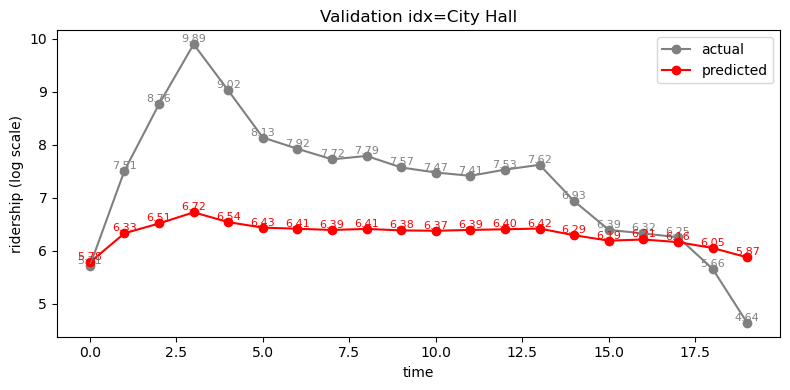

Validation:  17%|█▋        | 1/6 [00:00<00:01,  2.62it/s]

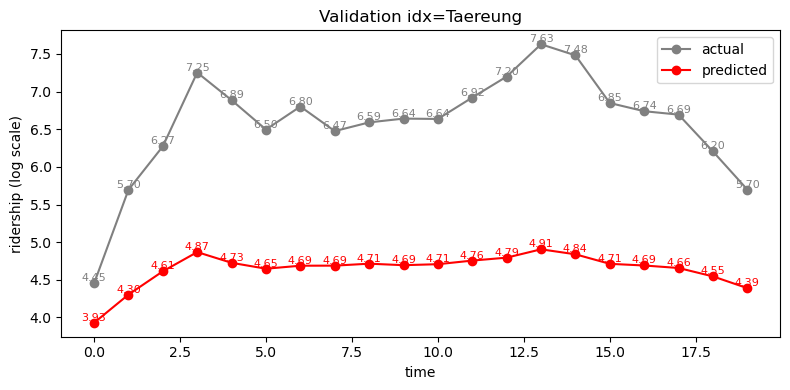

Validation:  33%|███▎      | 2/6 [00:00<00:01,  2.74it/s]

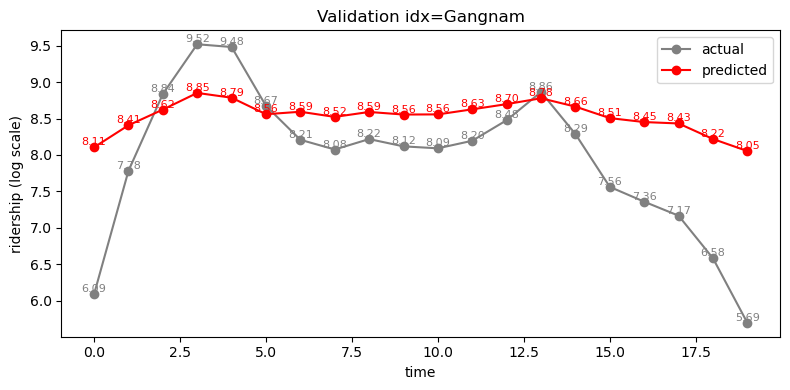

Validation:  50%|█████     | 3/6 [00:01<00:01,  2.16it/s]

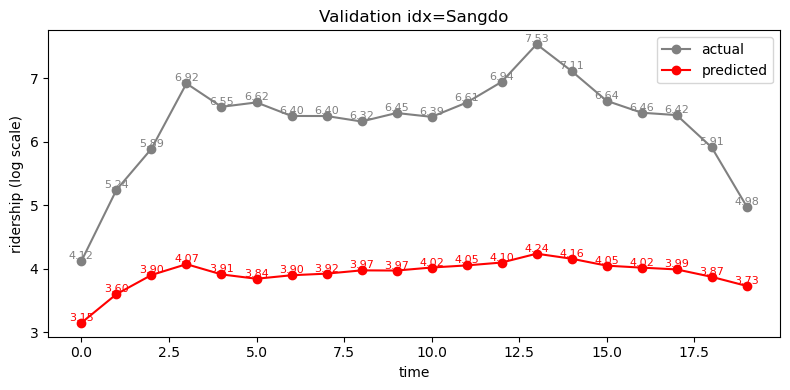

Validation:  67%|██████▋   | 4/6 [00:01<00:00,  2.14it/s]

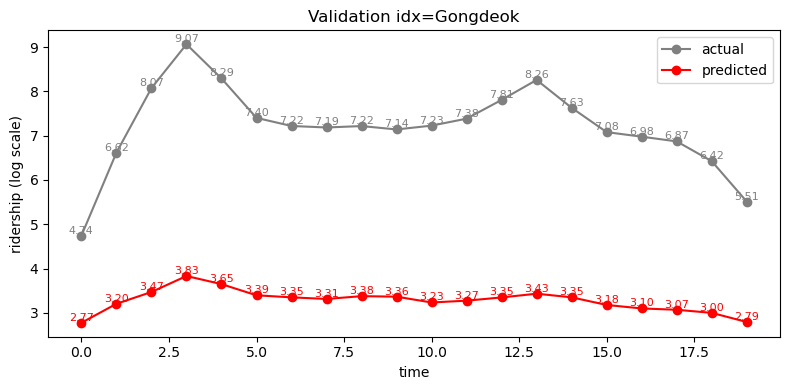

Validation:  83%|████████▎ | 5/6 [00:02<00:00,  2.03it/s]

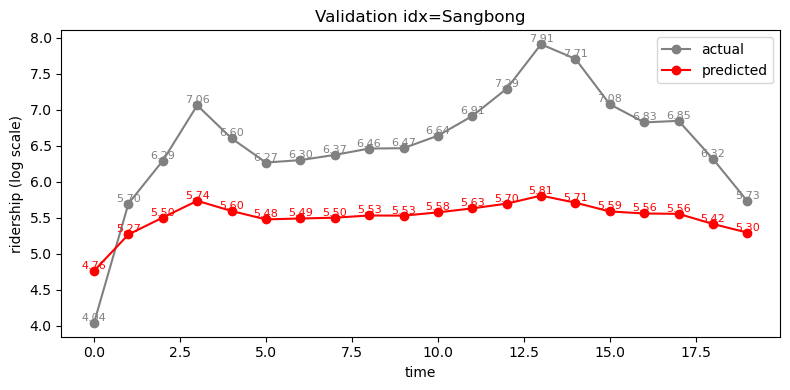

Validation: 100%|██████████| 6/6 [00:02<00:00,  2.20it/s]

Mean Absolute Error: 1.876150


In [10]:
warnings.filterwarnings('ignore')

mse = 0

for k, row in tqdm(val_input.iterrows(), total=len(val_input), desc="Validation"):
    # repeat df_x row for 20 time steps and stack with one-hot time vectors
    x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)
    ridership_vals = np.array(val_output.loc[k]).reshape(-1, 1)
    ridership_vals = np.where(ridership_vals == 0, 1, ridership_vals)
    temp_stack = np.hstack([time_onehots, x_rep])
    
    # Make predictions using the linear regression model

    inputs = temp_stack
    inputs_tensor = torch.tensor(inputs, dtype=torch.float)
        
    
    preds = svm_model.predict(inputs_tensor)
    
    #preds = preds.detach().cpu().numpy().flatten()
    ridership_flat = np.log(ridership_vals).flatten()
    
    # record results and update mse
    mse += np.mean(np.abs(preds.flatten() - ridership_flat))
    
    # plot actual (grey) vs predicted (red)
    plt.figure(figsize=(8, 4))
    plt.plot(range(len(ridership_flat)), ridership_flat, color='grey', marker='o', label='actual')
    plt.plot(range(len(preds)), preds, color='red', marker='o', label='predicted')
    

    # station name
    st_name = df.loc[k]['en_name']


    for t in range(len(ridership_flat)):
        plt.text(t, float(ridership_flat[t]), f"{float(ridership_flat[t]):.2f}", color='grey', ha='center', va='bottom', fontsize=8)
        plt.text(t, float(preds[t]), f"{float(preds[t]):.2f}", color='red', ha='center', va='bottom', fontsize=8)
        plt.xlabel('time')
    plt.ylabel('ridership (log scale)')
    plt.title(f'Validation idx={st_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

print(f"Mean Absolute Error: {mse / len(val_input):.6f}")


# RF

In [11]:
from sklearn.ensemble import RandomForestRegressor

# Create and train Random Forest regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(train_x, np.log(train_y.flatten()))

# Get R² score
r2_score = rf_model.score(train_x, np.log(train_y.flatten()))
print(f"R² Score: {r2_score:.6f}")
print("Training complete!")


R² Score: 0.978707
Training complete!


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

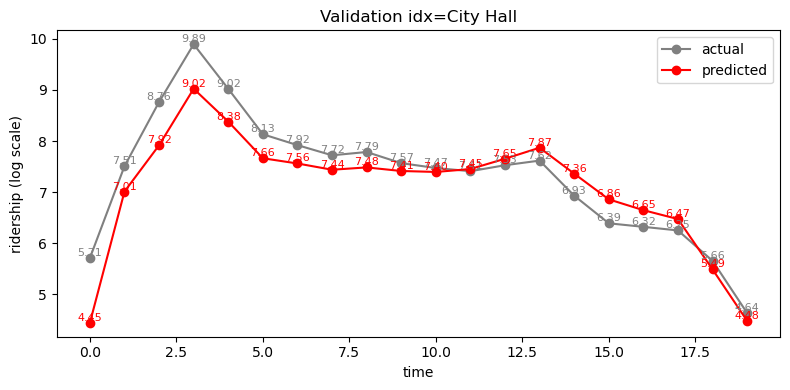

Validation:  17%|█▋        | 1/6 [00:00<00:04,  1.19it/s]

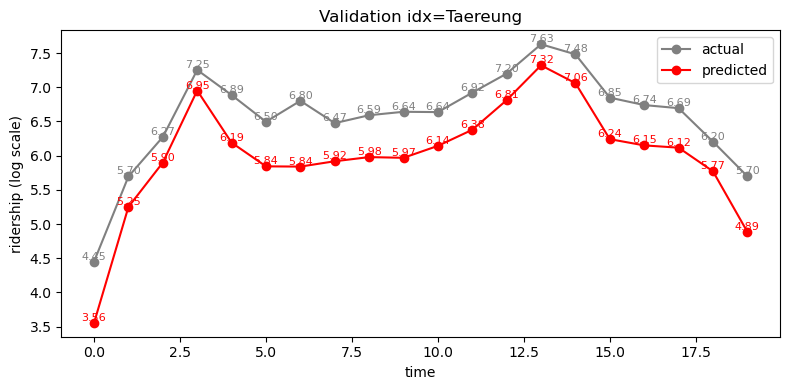

Validation:  33%|███▎      | 2/6 [00:01<00:03,  1.32it/s]

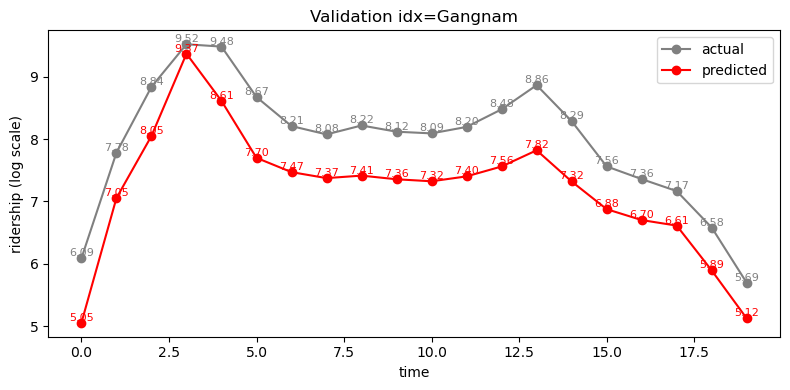

Validation:  50%|█████     | 3/6 [00:02<00:02,  1.43it/s]

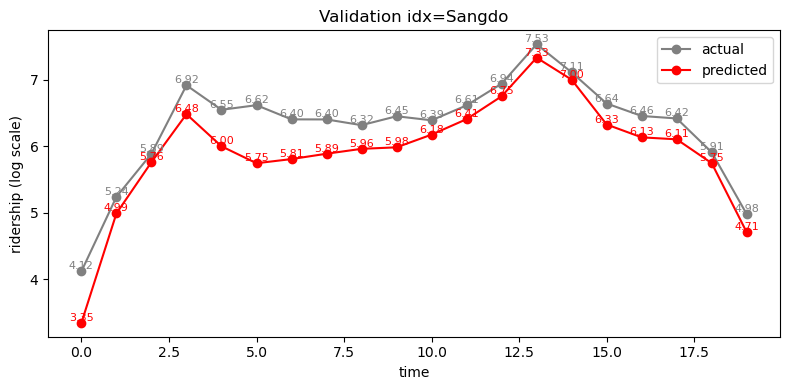

Validation:  67%|██████▋   | 4/6 [00:02<00:01,  1.64it/s]

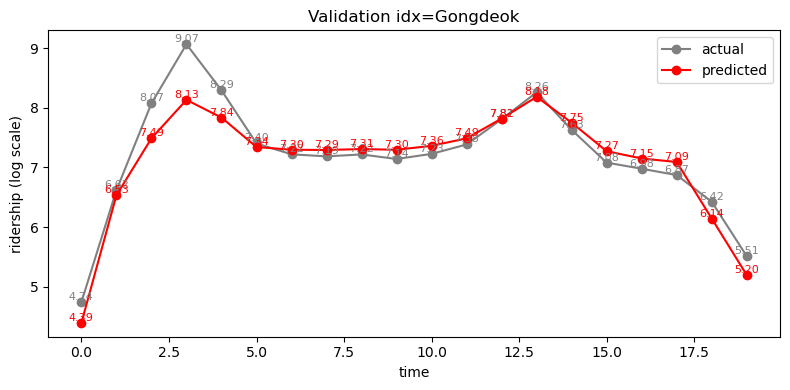

Validation:  83%|████████▎ | 5/6 [00:03<00:00,  1.74it/s]

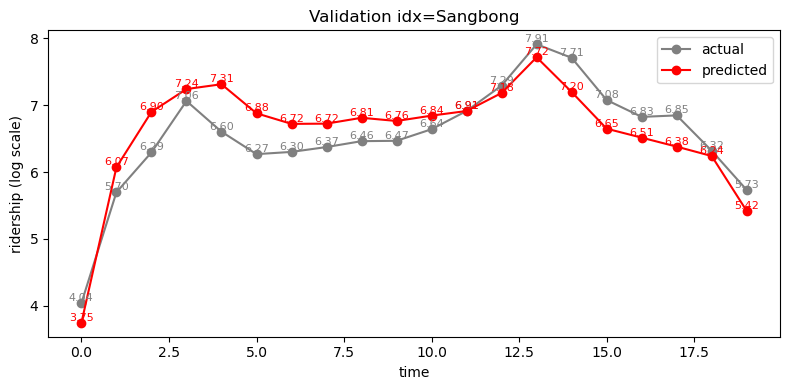

Validation: 100%|██████████| 6/6 [00:03<00:00,  1.64it/s]

Mean Absolute Error: 0.442261


In [44]:
warnings.filterwarnings('ignore')

mse = 0

for k, row in tqdm(val_input.iterrows(), total=len(val_input), desc="Validation"):
    # repeat df_x row for 20 time steps and stack with one-hot time vectors
    x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)
    ridership_vals = np.array(val_output.loc[k]).reshape(-1, 1)
    ridership_vals = np.where(ridership_vals == 0, 1, ridership_vals)
    temp_stack = np.hstack([time_onehots, x_rep])
    
    # Make predictions using the linear regression model

    inputs = temp_stack
    inputs_tensor = torch.tensor(inputs, dtype=torch.float)
        
    
    preds = rf_model.predict(inputs_tensor)
    
    #preds = preds.detach().cpu().numpy().flatten()
    ridership_flat = np.log(ridership_vals).flatten()
    
    # record results and update mse
    mse += np.mean(np.abs(preds.flatten() - ridership_flat))
    
    # plot actual (grey) vs predicted (red)
    plt.figure(figsize=(8, 4))
    plt.plot(range(len(ridership_flat)), ridership_flat, color='grey', marker='o', label='actual')
    plt.plot(range(len(preds)), preds, color='red', marker='o', label='predicted')
    

    # station name
    st_name = df.loc[k]['en_name']


    for t in range(len(ridership_flat)):
        plt.text(t, float(ridership_flat[t]), f"{float(ridership_flat[t]):.2f}", color='grey', ha='center', va='bottom', fontsize=8)
        plt.text(t, float(preds[t]), f"{float(preds[t]):.2f}", color='red', ha='center', va='bottom', fontsize=8)
        plt.xlabel('time')
    plt.ylabel('ridership (log scale)')
    plt.title(f'Validation idx={st_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

print(f"Mean Absolute Error: {mse / len(val_input):.6f}")


## BNN Model

In [13]:
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample

In [14]:
class BNN(nn.Module):
    def __init__(self, input_dim = 20, hidden_dim = 20,  output_dim = 1, prior_scale = 10000.):
        super(BNN, self).__init__()
        
        self.activation = nn.ReLU()

        # First layer
        self.layer1 = PyroModule[nn.Linear](input_dim, hidden_dim)
        self.layer1._pyro_name = "layer1"
        self.layer1.weight = PyroSample(dist.Normal(0., prior_scale).expand([hidden_dim, input_dim]).to_event(2))
        self.layer1.bias = PyroSample(dist.Normal(0., prior_scale).expand([hidden_dim]).to_event(1))
        
        # Second layer
        self.layer2 = PyroModule[nn.Linear](hidden_dim, 10)
        self.layer2._pyro_name = "layer2"
        self.layer2.weight = PyroSample(dist.Normal(0., prior_scale).expand([10, hidden_dim]).to_event(2))
        self.layer2.bias = PyroSample(dist.Normal(0., prior_scale).expand([10]).to_event(1))

        # Third layer for mu
        self.layer3 = PyroModule[nn.Linear](10, output_dim)
        self.layer3._pyro_name = "layer3"
        self.layer3.weight = PyroSample(dist.Normal(0., prior_scale).expand([output_dim, 10]).to_event(2))
        self.layer3.bias = PyroSample(dist.Normal(0., prior_scale).expand([output_dim]).to_event(1))

        # Fourth layer for sigma
        self.layer4 = PyroModule[nn.Linear](10, output_dim)
        self.layer4._pyro_name = "layer4"
        self.layer4.weight = PyroSample(dist.Normal(0., 1000).expand([output_dim, 10]).to_event(2))
        self.layer4.bias = PyroSample(dist.Normal(0., 1000).expand([output_dim]).to_event(1))
        
    def forward(self, x, y=None):
        x = self.activation(self.layer1(x))
        x = self.activation(self.layer2(x))
        mu = self.activation(self.layer3(x)).squeeze(-1)
        
        # Input-dependent sigma
        sigma = torch.nn.functional.softplus(self.layer4(x)+ 1e-6).squeeze(-1)+ 1e-6

        pyro.deterministic("mu", mu)
        pyro.deterministic("sigma", sigma)
        
        with pyro.plate("data", size=mu.shape[0]):
            pyro.sample("coefs", dist.Normal(mu, sigma), obs=y)
        return mu, sigma

model = BNN(input_dim = 37, output_dim = 20)

## Model comparison

In [21]:
import pickle
from pyro.infer import Predictive

# Load the trained model and guide
model_path = 'trained_model.pkl'
guide_path = 'trained_guide.pkl'

with open(model_path, 'rb') as f:
    bnn_model = pickle.load(f)

with open(guide_path, 'rb') as f:
    guide = pickle.load(f)

print(f"Model loaded from {model_path}")
print(f"Guide loaded from {guide_path}")

num_samples = 500

Model loaded from trained_model.pkl
Guide loaded from trained_guide.pkl


 Validation:   0%|          | 0/6 [00:00<?, ?it/s]

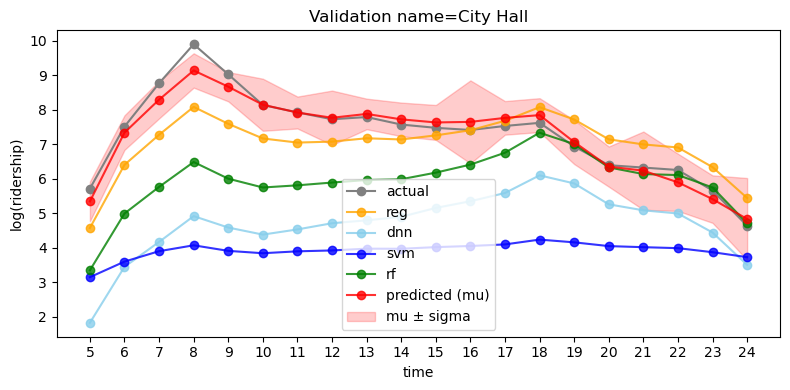

 Validation:  17%|█▋        | 1/6 [00:15<01:18, 15.67s/it]

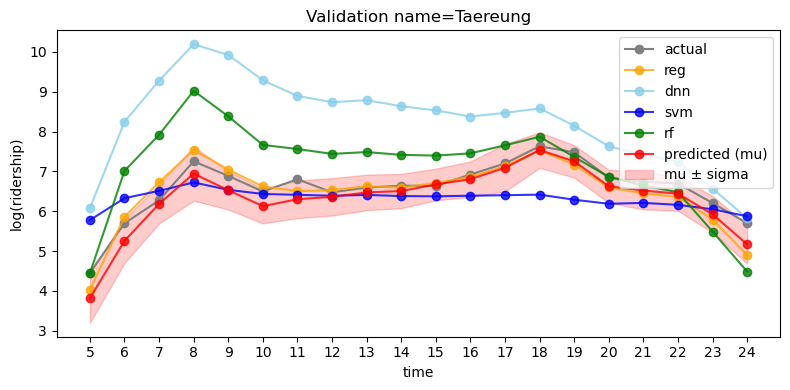

 Validation:  33%|███▎      | 2/6 [00:29<00:59, 14.85s/it]

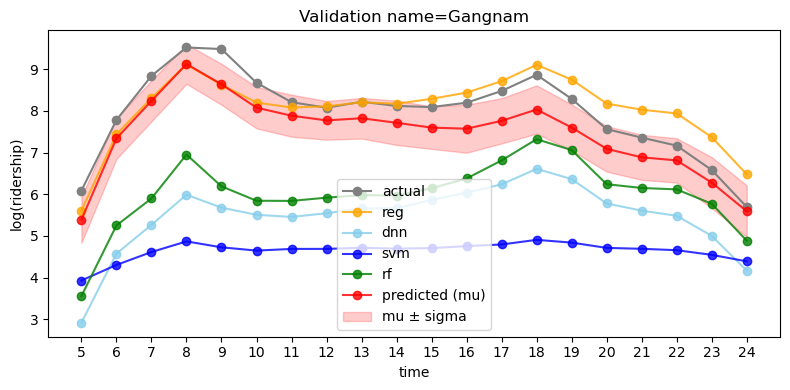

 Validation:  50%|█████     | 3/6 [00:39<00:37, 12.52s/it]

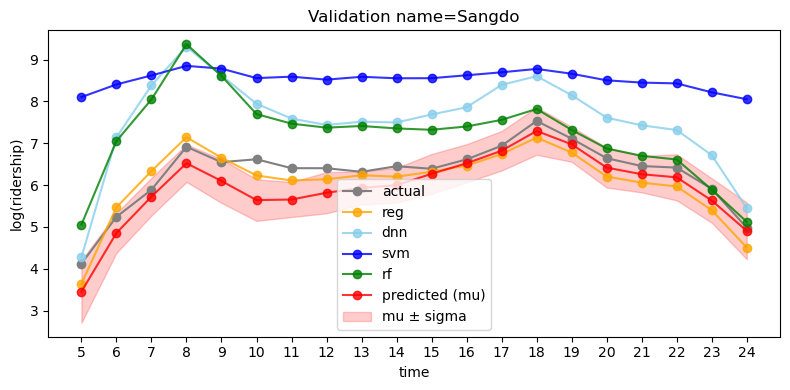

 Validation:  67%|██████▋   | 4/6 [00:49<00:22, 11.33s/it]

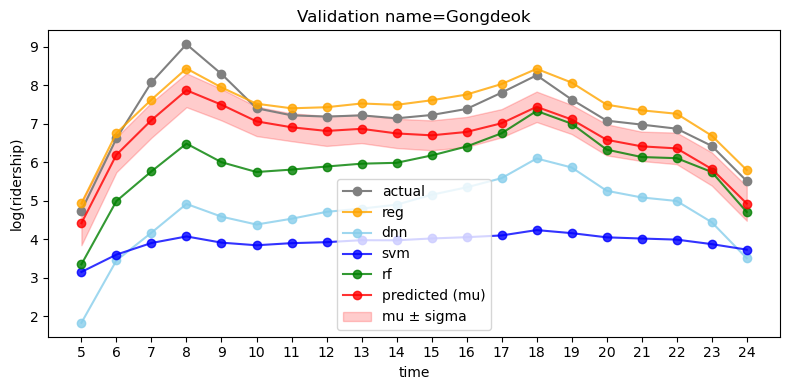

 Validation:  83%|████████▎ | 5/6 [00:57<00:10, 10.41s/it]

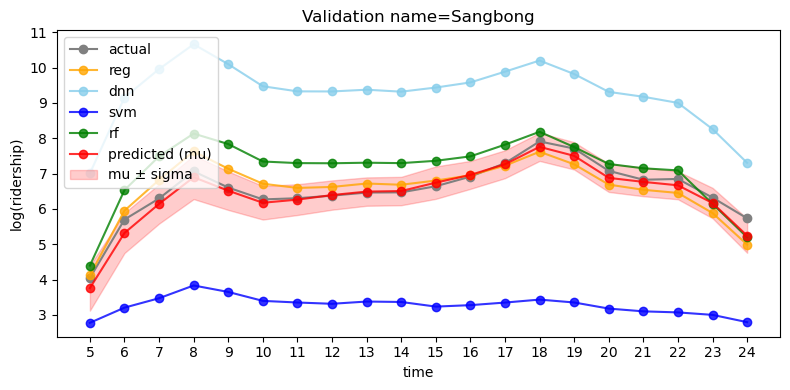

 Validation: 100%|██████████| 6/6 [01:07<00:00, 11.27s/it]

47.87126899411531 266.17649203241757 320.02950699800755 138.82415715707202 40.92599753247005


In [24]:

reg_mse, dnn_mse, svm_mse, rf_mse, bnn_mse = 0, 0, 0, 0, 0

for k, row in tqdm(val_input.iterrows(), total=len(val_input), desc=f" Validation"):
    # repeat df_x row for 20 time steps and stack with one-hot time vectors and ridership
    x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)
    ridership_vals = np.array(val_output.loc[k]).reshape(-1, 1)
    ridership_vals = np.where(ridership_vals == 0, 1, ridership_vals) # avoid log(0)
    temp_stack = np.hstack([time_onehots, x_rep])

    ridership_flat = np.log(ridership_vals).flatten()


    ## Reg
    reg_preds = reg_model.predict(temp_stack)# record results and update mse

    ## DNN
    with torch.no_grad():
        dnn_preds = dnn_model(inputs_tensor)
    dnn_preds = dnn_preds.detach().cpu().numpy().flatten()

    ## SVM
    svm_preds = svm_model.predict(inputs_tensor)

    ## RF
    rf_preds = rf_model.predict(inputs_tensor)
    

    result_list = []

    inputs = temp_stack
    inputs_tensor = torch.tensor(inputs, dtype=torch.float)
        
    with torch.no_grad():
        preds = Predictive(bnn_model, guide=guide, num_samples=num_samples)(inputs_tensor)
        mus = preds['coefs'].mean(axis=0).numpy()
        sigmas = preds['coefs'].std(axis=0).numpy()


    # record results and update mse
    for t in range(len(mus)):
        reg_mse += abs(float(reg_preds[t]) - float(ridership_flat[t]))
        dnn_mse += abs(float(dnn_preds[t]) - float(ridership_flat[t]))
        svm_mse += abs(float(svm_preds[t]) - float(ridership_flat[t]))
        rf_mse += abs(float(rf_preds[t]) - float(ridership_flat[t]))
        bnn_mse += abs(float(mus[t]) - float(ridership_flat[t]))

    # station name
    st_name = df.loc[k]['en_name']

    # plot actual (grey) vs predicted mu (red) with uncertainty band
    plt.figure(figsize=(8, 4))
    plt.plot(range(len(ridership_flat)), ridership_flat, color='grey', marker='o', label='actual')
    plt.plot(range(len(reg_preds)), reg_preds, color='orange', marker='o', label='reg', alpha = 0.8)
    plt.plot(range(len(dnn_preds)), dnn_preds, color='skyblue', marker='o', label='dnn', alpha = 0.8)
    plt.plot(range(len(svm_preds)), svm_preds, color='blue', marker='o', label='svm', alpha = 0.8)
    plt.plot(range(len(rf_preds)), rf_preds, color='green', marker='o', label='rf', alpha = 0.8)
    plt.plot(range(len(mus)), mus, color='red', marker='o', label='predicted (mu)', alpha = 0.8)
    plt.fill_between(range(len(mus)), mus - sigmas, mus + sigmas, color='red', alpha=0.2, label='mu ± sigma')
    y_max = max(np.max(mus), np.max(ridership_flat))
    y_min = min(np.min(mus), np.min(ridership_flat))
    offset = (y_max - y_min) * 0.02 if y_max != y_min else 0.1
    plt.xticks(range(len(mus)), range(5, 25))
    '''
    for t in range(len(mus)):
        plt.text(t, float(ridership_flat[t]) + offset, f"{float(ridership_flat[t]):.2f}", color='grey', ha='center', va='bottom', fontsize=8)
        plt.text(t, float(mus[t]) + offset * 1.2, f"{float(mus[t]):.2f}", color='red', ha='center', va='bottom', fontsize=8)
    '''    
    plt.xlabel('time')
    plt.ylabel('log(ridership)')
    plt.title(f'Validation name={st_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()
print(reg_mse, dnn_mse, svm_mse, rf_mse, bnn_mse)

In [ ]:
import pickle
#date_test = date_test2
# Load the trained model and guide
model_path = f'trained_model.pkl'
guide_path = f'trained_guide.pkl'

with open(model_path, 'rb') as f:
    model = pickle.load(f)

with open(guide_path, 'rb') as f:
    guide = pickle.load(f)

print(f"Model loaded from {model_path}")
print(f"Guide loaded from {guide_path}")

num_samples = 50
num_iters = 50000
input_dim = 37
output_dim = 20
prior_scale = 10.
learning_rate = 0.0005

total_mse = 0

for k, row in tqdm(enumerate(test_stations), total=len(val_input), desc=f" Validation"):
    print(row)
    mse = 0
    # repeat df_x row for 20 time steps and stack with one-hot time vectors and ridership
    x_rep = np.tile(val_input.iloc[k].values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)

    test_output_ids = df_date[(df_date['date'].isin(date_test)) & (df_date['name']==test_stations[k])].index
    test_output_df = df_y['ridership'].iloc[test_output_ids]
    ridership_val_arr = np.array(test_output_df)

    ridership_vals = np.array(test_output_df.mean()).reshape(-1, 1)
    ridership_vals = np.where(ridership_vals == 0, 1, ridership_vals) # avoid log(0)
    temp_stack = np.hstack([time_onehots, x_rep])

    result_list = []

    inputs = temp_stack
    inputs_tensor = torch.tensor(inputs, dtype=torch.float)
        
    with torch.no_grad():
        preds = Predictive(model, guide=guide, num_samples=num_samples)(inputs_tensor)
        mus = preds['coefs'].mean(axis=0).numpy()
        sigmas = preds['coefs'].std(axis=0).numpy()
        
        # Calculate 50% confidence interval (25th to 75th percentile)
        mus_ci50_lower = np.percentile(preds['coefs'], 25, axis=0)
        mus_ci50_upper = np.percentile(preds['coefs'], 75, axis=0)
        
        # Calculate 90% confidence interval (5th to 95th percentile)
        mus_ci90_lower = np.percentile(preds['coefs'], 5, axis=0)
        mus_ci90_upper = np.percentile(preds['coefs'], 95, axis=0)

    ridership_flat = np.log(ridership_vals).flatten()

    # record results and update mse
    for t in range(len(mus)):
        mse += abs(float(mus[t]) - float(ridership_flat[t]))
        total_mse += mse

    # station name
    st_name = df_date.loc[test_output_ids[0]]['en_name']

    # plot actual (grey) vs predicted mu (red) with uncertainty band
    plt.figure(figsize=(8, 4))
    plt.plot(range(len(ridership_flat)), ridership_flat, color='black', marker='o', label='actual_mean')
    plt.plot(range(len(mus)), mus, color='red', marker='o', label='predicted (mu)')
    plt.fill_between(range(len(mus)), mus_ci90_lower, mus_ci90_upper, color='yellow', alpha=0.2, label='90% CI')
    plt.fill_between(range(len(mus)), mus - sigmas, mus + sigmas, color='orange', alpha=0.2, label='mu ± sigma')
    plt.fill_between(range(len(mus)), mus_ci50_lower, mus_ci50_upper, color='red', alpha=0.2, label='50% CI')
    
    for ridership_val in ridership_val_arr:
        plt.plot(range(len(ridership_flat)), np.log(ridership_val), color='gray', alpha = 0.7, linewidth = 0.75, linestyle = 'dashed')
    y_max = max(np.max(mus), np.max(ridership_flat))
    y_min = min(np.min(mus), np.min(ridership_flat))
    offset = (y_max - y_min) * 0.02 if y_max != y_min else 0.1
    plt.xticks(range(len(mus)), range(5, 25))

    for t in range(len(mus)):
        plt.text(t, float(ridership_flat[t]) + offset, f"{float(ridership_flat[t]):.2f}", color='black', ha='center', va='bottom', fontsize=8)
        plt.text(t, float(mus[t]) + offset * 1.2, f"{float(mus[t]):.2f}", color='red', ha='center', va='bottom', fontsize=8)
    plt.xlabel('time')
    plt.ylabel('ridership')
    plt.title(f'Validation name={st_name} AE = {mse:.2f} MeanUncertainty: {np.mean(sigmas):.2f}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'../Result/251216_DateTest/Test{test_number}_Validation_{st_name}.png')
    plt.show()
    
    
print(mse)

In [30]:
# compute R² for DNN and BNN on the validation set
dnn_preds_all = []
bnn_preds_all = []
y_true_all = []

for k, row in train_input.iterrows():
    x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
    temp_stack = np.hstack([time_onehots, x_rep])
    inputs_tensor = torch.tensor(temp_stack, dtype=torch.float)

    with torch.no_grad():
        dnn_out = dnn_model(inputs_tensor).cpu().numpy().flatten()
        preds = Predictive(bnn_model, guide=guide, num_samples=num_samples)(inputs_tensor)
        bnn_mu = np.asarray(preds['coefs']).mean(axis=0)

    ridership_vals = np.array(train_output.loc[k]).reshape(-1, 1)
    ridership_vals = np.where(ridership_vals == 0, 1, ridership_vals)
    y_log = np.log(ridership_vals).flatten()

    dnn_preds_all.append(dnn_out)
    bnn_preds_all.append(bnn_mu)
    y_true_all.append(y_log)

y_true = np.concatenate(y_true_all)
dnn_pred = np.concatenate(dnn_preds_all)
bnn_pred = np.concatenate(bnn_preds_all)

def r2_score_np(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')

print(f"DNN R²: {r2_score_np(y_true, dnn_pred):.6f}")
print(f"BNN R²: {r2_score_np(y_true, bnn_pred):.6f}")

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/_zmq.py", line 179, in zmq.backend.cython._zmq._check_rc
    PyErr_CheckSignals()
KeyboardInterrupt: 


KeyboardInterrupt: 